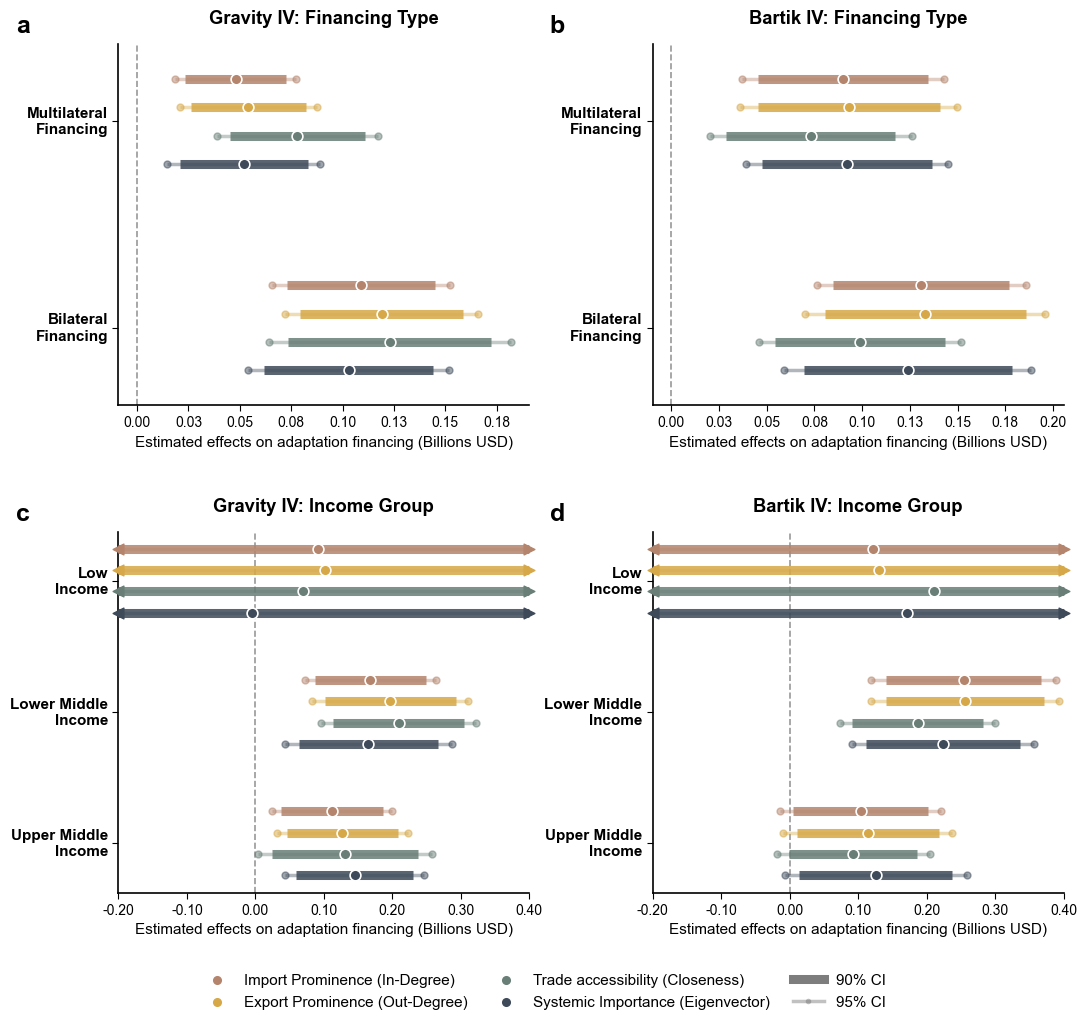

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ----------------------------------------------------
# 全局学术样式设置 (Nature Style)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2

COLORS = {
    'in_degree': '#B4846C',      
    'out_degree': '#D6A848',     
    'closeness': '#687E76',      
    'eigenvector': '#3E4A59'     
}

legend_names = {
    'in_degree': 'Import Prominence (In-Degree)',
    'out_degree': 'Export Prominence (Out-Degree)',
    'closeness': 'Trade accessibility (Closeness)',
    'eigenvector': 'Systemic Importance (Eigenvector)'
}

centralities = ['in_degree', 'out_degree', 'closeness', 'eigenvector']

# ----------------------------------------------------
# 数据读取函数化
# ----------------------------------------------------
def extract_numbers(text):
    return [float(x) for x in re.findall(r'-?\d+\.\d+', text)]

def load_data_a(filepath):
    """读取左侧图 (Bilateral vs Multilateral) 数据"""
    parsed_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()
    for i in range(len(lines) - 1):
        line = lines[i].lower()
        cent = 'in_degree' if 'in-degree' in line else 'out_degree' if 'out-degree' in line else 'closeness' if 'closeness' in line else 'eigenvector' if 'eigenvector' in line else None
        if cent:
            ames, ses = extract_numbers(lines[i]), extract_numbers(lines[i + 1])
            if len(ames) >= 2 and len(ses) >= 2:
                parsed_data += [
                    {'fund_type': 'Bilateral', 'centrality': cent, 'ame': ames[0], 'se': ses[0]},
                    {'fund_type': 'Multilateral', 'centrality': cent, 'ame': ames[1], 'se': ses[1]}
                ]
    df = pd.DataFrame(parsed_data)
    df['error_95'], df['error_90'] = 1.96 * df['se'], 1.645 * df['se']
    return df

def load_data_b(filepath):
    """读取右侧图 (Income groups) 数据"""
    parsed_data = []
    income_groups = ['Low_income', 'Lower_middle_income', 'Upper_middle_income']
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()
    for i in range(len(lines) - 1):
        line = lines[i].lower()
        cent = 'in_degree' if 'in-degree' in line else 'out_degree' if 'out-degree' in line else 'closeness' if 'closeness' in line else 'eigenvector' if 'eigenvector' in line else None
        if cent:
            ames, ses = extract_numbers(lines[i]), extract_numbers(lines[i + 1])
            if len(ames) >= 3 and len(ses) >= 3:
                parsed_data += [{'income_group': income_groups[j], 'centrality': cent, 'ame': ames[j], 'se': ses[j]} for j in range(3)]
    df = pd.DataFrame(parsed_data)
    df['error_95'], df['error_90'] = 1.96 * df['se'], 1.645 * df['se']
    return df

# ----------------------------------------------------
# 绘图逻辑函数化
# ----------------------------------------------------
def plot_panel_a(ax, df, title=""):
    """绘制面板 A (Bilateral vs Multilateral)"""
    y_categories = ['Bilateral', 'Multilateral']
    y_labels = ['Bilateral\nFinancing', 'Multilateral\nFinancing']
    y_pos = np.array([0.0, 0.8])
    offsets_l = {'in_degree': 0.165, 'out_degree': 0.055, 'closeness': -0.055, 'eigenvector': -0.165}

    for cent in centralities:
        d = df[df['centrality'] == cent].set_index('fund_type').reindex(y_categories)
        y = y_pos + offsets_l[cent]
        x = d['ame']
        x95_l, x95_u = d['ame'] - d['error_95'], d['ame'] + d['error_95']
        x90_l, x90_u = d['ame'] - d['error_90'], d['ame'] + d['error_90']

        ax.hlines(y, x95_l, x95_u, color=COLORS[cent], linewidth=2.5, alpha=0.4, zorder=1)
        ax.scatter(x95_l, y, color=COLORS[cent], s=25, alpha=0.5, zorder=2)
        ax.scatter(x95_u, y, color=COLORS[cent], s=25, alpha=0.5, zorder=2)
        ax.hlines(y, x90_l, x90_u, color=COLORS[cent], linewidth=6.5, alpha=0.85, zorder=3)
        ax.scatter(x, y, color=COLORS[cent], s=60, edgecolor='white', linewidth=1.2, zorder=4, label=legend_names[cent])

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, va='center', fontweight='bold')
    ax.set_ylim(-0.3, 1.1)
    if title: ax.set_title(title, fontweight='bold', pad=15)

def plot_panel_b(ax, df, title=""):
    """绘制面板 B (按收入群体，含截断处理)"""
    y_categories = ['Upper_middle_income', 'Lower_middle_income', 'Low_income']
    y_labels = ['Upper Middle\nIncome', 'Lower Middle\nIncome', 'Low\nIncome']
    y_pos = np.array([0.0, 0.8, 1.6])
    offsets = {'in_degree': 0.195, 'out_degree': 0.065, 'closeness': -0.065, 'eigenvector': -0.195}
    X_MIN, X_MAX = -0.2, 0.4

    for cent in centralities:
        d = df[df['centrality'] == cent].set_index('income_group').reindex(y_categories)
        y = y_pos + offsets[cent]
        x = d['ame']

        x95_l0, x95_u0 = d['ame'] - d['error_95'], d['ame'] + d['error_95']
        x90_l0, x90_u0 = d['ame'] - d['error_90'], d['ame'] + d['error_90']

        x95_l, x95_u = np.clip(x95_l0, X_MIN, X_MAX), np.clip(x95_u0, X_MIN, X_MAX)
        x90_l, x90_u = np.clip(x90_l0, X_MIN, X_MAX), np.clip(x90_u0, X_MIN, X_MAX)

        ax.hlines(y, x95_l, x95_u, color=COLORS[cent], linewidth=2.5, alpha=0.4, zorder=1)
        ax.scatter(x95_l, y, color=COLORS[cent], s=25, alpha=0.5, zorder=2)
        ax.scatter(x95_u, y, color=COLORS[cent], s=25, alpha=0.5, zorder=2)
        ax.hlines(y, x90_l, x90_u, color=COLORS[cent], linewidth=6.5, alpha=0.85, zorder=3)
        ax.scatter(x, y, color=COLORS[cent], s=60, edgecolor='white', linewidth=1.2, zorder=4, label=legend_names[cent])

        for yy, lo, hi in zip(y, x95_l0, x95_u0):
            if hi > X_MAX:
                ax.scatter(X_MAX, yy, marker='>', color=COLORS[cent], s=60, zorder=5, clip_on=False)
            if lo < X_MIN:
                ax.scatter(X_MIN, yy, marker='<', color=COLORS[cent], s=60, zorder=5, clip_on=False)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, va='center', fontweight='bold')
    ax.set_ylim(-0.3, 1.9)
    ax.set_xlim(X_MIN, X_MAX)
    if title: ax.set_title(title, fontweight='bold', pad=15)

# ----------------------------------------------------
# 🌟 开始绘制 2x2 组合图
# ----------------------------------------------------
# 加载数据
df_gravity_a = load_data_a("../regression_results_Bi_Multi_GravityIV_CF.csv")
df_gravity_b = load_data_b("../regression_results_GravityIV_CF_Bootstrap_by_income.csv")
df_bartik_a = load_data_a("../regression_results_Bi_Multi_BartikIV_CF.csv")
df_bartik_b = load_data_b("../regression_results_BartikIV_CF_Bootstrap_by_income.csv")

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

plot_panel_a(axes[0, 0], df_gravity_a, title="Gravity IV: Financing Type")   # a
plot_panel_a(axes[0, 1], df_bartik_a, title="Bartik IV: Financing Type")    # b
plot_panel_b(axes[1, 0], df_gravity_b, title="Gravity IV: Income Group")    # c
plot_panel_b(axes[1, 1], df_bartik_b, title="Bartik IV: Income Group")      # d

# 坐标轴统一样式调整
for ax in axes.flat:
    ax.axvline(0, color='#333333', linestyle='--', linewidth=1.2, alpha=0.5, zorder=0)
    ax.set_xlabel('Estimated effects on adaptation financing (Billions USD)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:.2f}"))
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4)

# ----------------------------------------------------
# 提取图例并放置在底部
# ----------------------------------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ci_handles = [
    Line2D([0], [0], color='#666666', lw=6.5, alpha=0.85, label='90% CI'),
    Line2D([0], [0], color='#666666', lw=2.5, alpha=0.4, marker='o', markersize=4, markeredgewidth=0, label='95% CI')
]

fig.legend(
    list(by_label.values()) + ci_handles,
    list(by_label.keys()) + [h.get_label() for h in ci_handles],
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.03), # 调整底部图例位置
    ncol=3, 
    frameon=False, 
    columnspacing=1.5
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.10, hspace=0.35, wspace=0.3)

# 添加 a, b, c, d 标签
labels_letters = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axes.flat):
    # 使用 transAxes 将标签锚定在每个子图的左上角外部
    ax.text(-0.25, 1.05, labels_letters[i], transform=ax.transAxes, 
            fontsize=18, fontweight='bold', va='center', ha='left')

plt.savefig("Final/Fig.5.pdf", format='pdf', bbox_inches='tight')
plt.savefig("Final/Fig.5.png", dpi=1200, bbox_inches='tight')

plt.show()